In [ ]:
# This mounts your Google Drive to the Colab VM.
#from google.colab import drive
#drive.mount('/content/drive')

# TODO: Enter the foldername in your Drive where you have saved the unzipped
# assignment folder, e.g. 'cs231n/assignments/assignment1/'
FOLDERNAME = 'cs231n/assignments/assignment1/'
assert FOLDERNAME is not None, "[!] Enter the foldername."

# Now that we've mounted your Drive, this ensures that
# the Python interpreter of the Colab VM can load
# python files from within it.
import sys
sys.path.append('/content/drive/My Drive/{}'.format(FOLDERNAME))

# This downloads the CIFAR-10 dataset to your Drive
# if it doesn't already exist.
%cd /content/drive/My\ Drive/$FOLDERNAME/cs231n/datasets/
# %cd /content/drive/My\ Drive/$FOLDERNAME
!bash get_datasets.sh
%cd /content/drive/My\ Drive/$FOLDERNAME

# Multi-Layer Fully Connected Network
In this exercise, you will implement a fully connected network with an arbitrary number of hidden layers.

In [ ]:
# from google.colab import drive
# drive.mount('/content/drive')

Read through the `FullyConnectedNet` class in the file `cs231n/classifiers/fc_net.py`.

Implement the network initialization, forward pass, and backward pass. Throughout this assignment, you will be implementing layers in `cs231n/layers.py`. You can re-use your implementations for `affine_forward`, `affine_backward`, `relu_forward`, `relu_backward`, and `softmax_loss` from before. For right now, don't worry about implementing dropout or batch/layer normalization yet, as you will add those features later.


In [2]:
# Setup cell.
import sys
import os
module_path = '/Users/annie/Desktop/图像编辑论文/cs231n/assignment1'
if module_path not in sys.path:
    sys.path.append(os.path.abspath(module_path))
import time
import numpy as np
import matplotlib.pyplot as plt
from cs231n.classifiers.fc_net import *
from cs231n.data_utils import get_CIFAR10_data
from cs231n.gradient_check import eval_numerical_gradient, eval_numerical_gradient_array
from cs231n.solver import Solver

%matplotlib inline
plt.rcParams["figure.figsize"] = (10.0, 8.0)  # Set default size of plots.
plt.rcParams["image.interpolation"] = "nearest"
plt.rcParams["image.cmap"] = "gray"

%load_ext autoreload
%autoreload 2

def rel_error(x, y):
    """Returns relative error."""
    return np.max(np.abs(x - y) / (np.maximum(1e-8, np.abs(x) + np.abs(y))))

In [3]:
# Load the (preprocessed) CIFAR-10 data.
data = get_CIFAR10_data()
for k, v in list(data.items()):
    print(f"{k}: {v.shape}")

X_train: (49000, 3, 32, 32)
y_train: (49000,)
X_val: (1000, 3, 32, 32)
y_val: (1000,)
X_test: (1000, 3, 32, 32)
y_test: (1000,)


## Initial Loss and Gradient Check

As a sanity check, run the following to check the initial loss and to gradient check the network both with and without regularization. This is a good way to see if the initial losses seem reasonable.

For gradient checking, you should expect to see errors around 1e-7 or less.

In [6]:
np.random.seed(231)
N, D, H1, H2, C = 2, 15, 20, 30, 10
X = np.random.randn(N, D)
y = np.random.randint(C, size=(N,))

for reg in [0, 3.14]:
    print("Running check with reg = ", reg)
    model = FullyConnectedNet(
        [H1, H2],
        input_dim=D,
        num_classes=C,
        reg=reg,
        weight_scale=5e-2,
        dtype=np.float64
    )

    loss, grads = model.loss(X, y)
    print("Initial loss: ", loss)

    # Most of the errors should be on the order of e-7 or smaller.
    # NOTE: It is fine however to see an error for W2 on the order of e-5
    # for the check when reg = 0.0
    for name in sorted(grads):
        f = lambda _: model.loss(X, y)[0]
        grad_num = eval_numerical_gradient(f, model.params[name], verbose=False, h=1e-5)
        print(f"{name} relative error: {rel_error(grad_num, grads[name])}")

Running check with reg =  0
Initial loss:  2.300479089768492
W1 relative error: 1.0252674374835853e-07
W2 relative error: 2.2120479343503063e-05
W3 relative error: 4.5623278699709044e-07
b1 relative error: 4.660094372886962e-09
b2 relative error: 2.085654276112763e-09
b3 relative error: 1.689724888469736e-10
Running check with reg =  3.14
Initial loss:  7.052114776533016
W1 relative error: 3.904542008453064e-09
W2 relative error: 3.522821562176466e-08
W3 relative error: 3.483989217647104e-08
b1 relative error: 1.4752427323253937e-08
b2 relative error: 1.4615869332918208e-09
b3 relative error: 1.3200479211447775e-10


As another sanity check, make sure your network can overfit on a small dataset of 50 images. First, we will try a three-layer network with 100 units in each hidden layer. In the following cell, tweak the **learning rate** and **weight initialization scale** to overfit and achieve 100% training accuracy within 20 epochs.

(Iteration 1 / 40) loss: 2.375113
(Epoch 0 / 20) train acc: 0.220000; val_acc: 0.091000
(Epoch 1 / 20) train acc: 0.240000; val_acc: 0.096000
(Epoch 2 / 20) train acc: 0.460000; val_acc: 0.152000
(Epoch 3 / 20) train acc: 0.560000; val_acc: 0.121000
(Epoch 4 / 20) train acc: 0.620000; val_acc: 0.165000
(Epoch 5 / 20) train acc: 0.620000; val_acc: 0.158000
(Iteration 11 / 40) loss: 1.094711
(Epoch 6 / 20) train acc: 0.820000; val_acc: 0.173000
(Epoch 7 / 20) train acc: 0.800000; val_acc: 0.171000
(Epoch 8 / 20) train acc: 0.860000; val_acc: 0.172000
(Epoch 9 / 20) train acc: 0.980000; val_acc: 0.198000
(Epoch 10 / 20) train acc: 0.940000; val_acc: 0.183000
(Iteration 21 / 40) loss: 0.278962
(Epoch 11 / 20) train acc: 0.980000; val_acc: 0.177000
(Epoch 12 / 20) train acc: 0.980000; val_acc: 0.196000
(Epoch 13 / 20) train acc: 0.960000; val_acc: 0.169000
(Epoch 14 / 20) train acc: 0.980000; val_acc: 0.177000
(Epoch 15 / 20) train acc: 0.980000; val_acc: 0.187000
(Iteration 31 / 40) loss: 

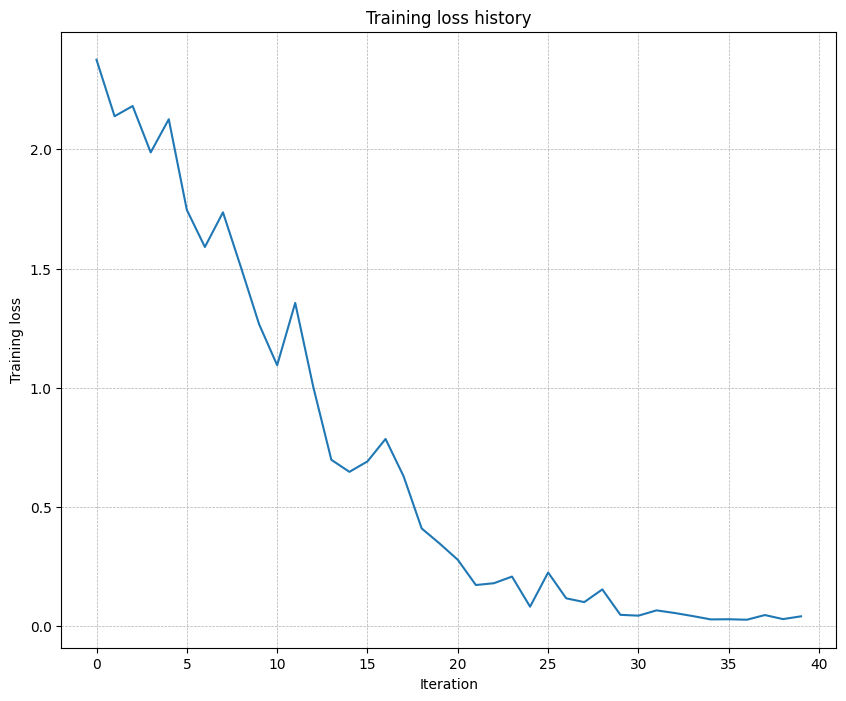

In [8]:
# TODO: Use a three-layer Net to overfit 50 training examples by
# tweaking just the learning rate and initialization scale.

num_train = 50
small_data = {
  "X_train": data["X_train"][:num_train],
  "y_train": data["y_train"][:num_train],
  "X_val": data["X_val"],
  "y_val": data["y_val"],
}

weight_scale = 1e-2   # Experiment with this!
learning_rate = 1e-2  # Experiment with this!


model = FullyConnectedNet(
    [100, 100],
    weight_scale=weight_scale,
    dtype=np.float64
)
solver = Solver(
    model,
    small_data,
    print_every=10,
    num_epochs=20,
    batch_size=25,
    update_rule="sgd",
    optim_config={"learning_rate": learning_rate},
)
solver.train()

plt.plot(solver.loss_history)
plt.title("Training loss history")
plt.xlabel("Iteration")
plt.ylabel("Training loss")
plt.grid(linestyle='--', linewidth=0.5)
plt.show()

Now, try to use a five-layer network with 100 units on each layer to overfit on 50 training examples. Again, you will have to adjust the learning rate and weight initialization scale, but you should be able to achieve 100% training accuracy within 20 epochs.

训练模型 1/100, learning_rate=0.010000,weight_scale=0.010000
训练模型 2/100, learning_rate=0.010000,weight_scale=0.012915
训练模型 3/100, learning_rate=0.010000,weight_scale=0.016681
训练模型 4/100, learning_rate=0.010000,weight_scale=0.021544
训练模型 5/100, learning_rate=0.010000,weight_scale=0.027826
训练模型 6/100, learning_rate=0.010000,weight_scale=0.035938
训练模型 7/100, learning_rate=0.010000,weight_scale=0.046416
训练模型 8/100, learning_rate=0.010000,weight_scale=0.059948
训练模型 9/100, learning_rate=0.010000,weight_scale=0.077426
训练模型 10/100, learning_rate=0.010000,weight_scale=0.100000


/Users/annie/Desktop/图像编辑论文/cs231n/assignment1/cs231n/layers.py:727: RuntimeWarning: divide by zero encountered in log
  loss = -np.sum(np.log(p[np.arange(N), y]))
/Users/annie/Desktop/图像编辑论文/cs231n/assignment1/cs231n/layers.py:724: RuntimeWarning: invalid value encountered in subtract
  s -= np.max(s, axis=1, keepdims=True)


训练模型 11/100, learning_rate=0.012915,weight_scale=0.010000
训练模型 12/100, learning_rate=0.012915,weight_scale=0.012915
训练模型 13/100, learning_rate=0.012915,weight_scale=0.016681
训练模型 14/100, learning_rate=0.012915,weight_scale=0.021544
训练模型 15/100, learning_rate=0.012915,weight_scale=0.027826
训练模型 16/100, learning_rate=0.012915,weight_scale=0.035938
训练模型 17/100, learning_rate=0.012915,weight_scale=0.046416
训练模型 18/100, learning_rate=0.012915,weight_scale=0.059948
训练模型 19/100, learning_rate=0.012915,weight_scale=0.077426
训练模型 20/100, learning_rate=0.012915,weight_scale=0.100000


/Users/annie/Desktop/图像编辑论文/cs231n/assignment1/cs231n/classifiers/fc_net.py:332: RuntimeWarning: overflow encountered in multiply
  loss += self.reg * 0.5 * np.sum(W * W) # 正则化损失
/Users/annie/Desktop/图像编辑论文/cs231n/assignment1/cs231n/classifiers/fc_net.py:332: RuntimeWarning: invalid value encountered in scalar multiply
  loss += self.reg * 0.5 * np.sum(W * W) # 正则化损失


训练模型 21/100, learning_rate=0.016681,weight_scale=0.010000
训练模型 22/100, learning_rate=0.016681,weight_scale=0.012915
训练模型 23/100, learning_rate=0.016681,weight_scale=0.016681
训练模型 24/100, learning_rate=0.016681,weight_scale=0.021544
训练模型 25/100, learning_rate=0.016681,weight_scale=0.027826
训练模型 26/100, learning_rate=0.016681,weight_scale=0.035938
训练模型 27/100, learning_rate=0.016681,weight_scale=0.046416
训练模型 28/100, learning_rate=0.016681,weight_scale=0.059948
训练模型 29/100, learning_rate=0.016681,weight_scale=0.077426
训练模型 30/100, learning_rate=0.016681,weight_scale=0.100000
训练模型 31/100, learning_rate=0.021544,weight_scale=0.010000
训练模型 32/100, learning_rate=0.021544,weight_scale=0.012915
训练模型 33/100, learning_rate=0.021544,weight_scale=0.016681
训练模型 34/100, learning_rate=0.021544,weight_scale=0.021544
训练模型 35/100, learning_rate=0.021544,weight_scale=0.027826
训练模型 36/100, learning_rate=0.021544,weight_scale=0.035938
训练模型 37/100, learning_rate=0.021544,weight_scale=0.046416
训练模型 38/100, l

/Users/annie/Desktop/图像编辑论文/cs231n/assignment1/cs231n/layers.py:107: RuntimeWarning: invalid value encountered in multiply
  dx = dout * np.where(x > 0, 1, 0)
/Users/annie/opt/anaconda3/envs/assignment1/lib/python3.12/site-packages/numpy/_core/fromnumeric.py:86: RuntimeWarning: overflow encountered in reduce
  return ufunc.reduce(obj, axis, dtype, out, **passkwargs)


训练模型 40/100, learning_rate=0.021544,weight_scale=0.100000
训练模型 41/100, learning_rate=0.027826,weight_scale=0.010000
训练模型 42/100, learning_rate=0.027826,weight_scale=0.012915
训练模型 43/100, learning_rate=0.027826,weight_scale=0.016681
训练模型 44/100, learning_rate=0.027826,weight_scale=0.021544
训练模型 45/100, learning_rate=0.027826,weight_scale=0.027826
训练模型 46/100, learning_rate=0.027826,weight_scale=0.035938
训练模型 47/100, learning_rate=0.027826,weight_scale=0.046416
训练模型 48/100, learning_rate=0.027826,weight_scale=0.059948
训练模型 49/100, learning_rate=0.027826,weight_scale=0.077426
训练模型 50/100, learning_rate=0.027826,weight_scale=0.100000
训练模型 51/100, learning_rate=0.035938,weight_scale=0.010000
训练模型 52/100, learning_rate=0.035938,weight_scale=0.012915
训练模型 53/100, learning_rate=0.035938,weight_scale=0.016681
训练模型 54/100, learning_rate=0.035938,weight_scale=0.021544
训练模型 55/100, learning_rate=0.035938,weight_scale=0.027826
训练模型 56/100, learning_rate=0.035938,weight_scale=0.035938
训练模型 57/100, l

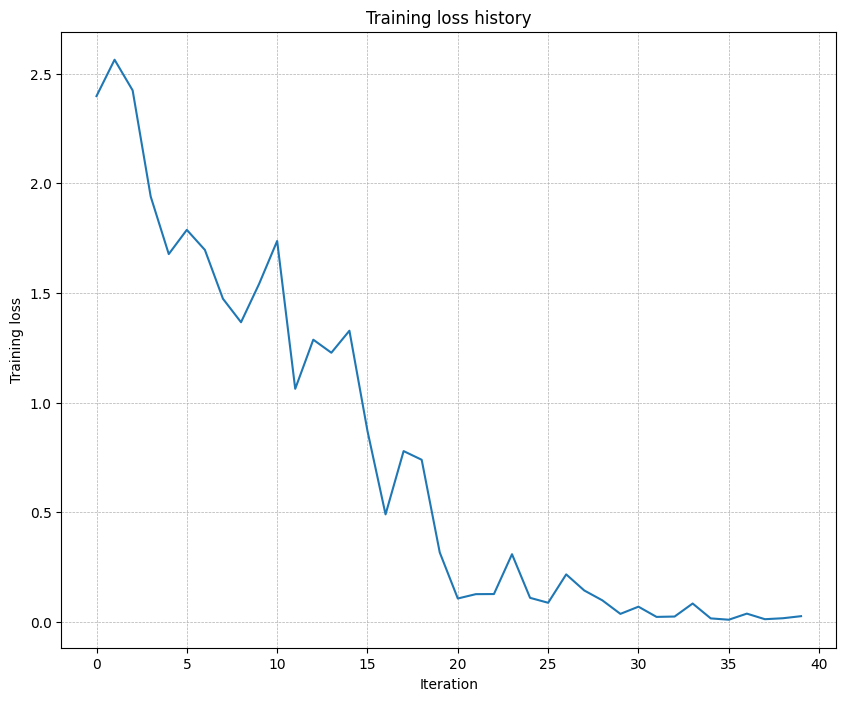

In [26]:
# TODO: Use a five-layer Net to overfit 50 training examples by
# tweaking just the learning rate and initialization scale.

num_train = 50
small_data = {
  'X_train': data['X_train'][:num_train],
  'y_train': data['y_train'][:num_train],
  'X_val': data['X_val'],
  'y_val': data['y_val'],
}

# learning_rate = 1e-2  # Experiment with this!
# weight_scale = 1e-2   # Experiment with this!
# 对原代码做了一些更改以保存最好的solver
best_val_accuracy = 0
best_learning_rate = 0
best_weight_scale = 0
best_train_accuracy = 0
best_model = None
best_solver = None

model_count = 0

for learning_rate in np.logspace(-2, -1, 10):
    for weight_scale in np.logspace(-2, -1, 10):
      model_count += 1
      print(f"训练模型 {model_count}/{100}, learning_rate={learning_rate:.6f},weight_scale={weight_scale:.6f}")

      model = FullyConnectedNet(
          [100, 100, 100, 100],
          weight_scale=weight_scale,
          dtype=np.float64
      )
      solver = Solver(
          model,
          small_data,
          print_every=10,
          num_epochs=20,
          batch_size=25,
          update_rule='sgd',
          optim_config={'learning_rate': learning_rate},
          verbose=False
      )
      solver.train()

      # 获取当前模型的训练准确率
      current_train_accuracy = max(solver.train_acc_history)

      if solver.best_val_acc > best_val_accuracy:
        best_solver = solver
        best_model = model
        best_val_accuracy = solver.best_val_acc
        best_learning_rate = learning_rate
        best_weight_scale = weight_scale
        best_train_accuracy = current_train_accuracy

# 输出最优模型的参数
print("\n最优模型参数:")
print("最佳验证准确率: ", best_val_accuracy)
print("最佳训练准确率: ", best_train_accuracy)
print("最佳学习率: ", best_learning_rate)
print("最佳权重初始化比例: ", best_weight_scale)

# 输出最优模型的训练历史
print("\n最优模型训练历史:")
for epoch, (train_acc, val_acc) in enumerate(zip(best_solver.train_acc_history, best_solver.val_acc_history)):
    print(f"Epoch {epoch+1}: 训练准确率 = {train_acc:.4f}, 验证准确率 = {val_acc:.4f}")

# 绘制最优模型的损失曲线
plt.plot(best_solver.loss_history)
plt.title('Training loss history')
plt.xlabel('Iteration')
plt.ylabel('Training loss')
plt.grid(linestyle='--', linewidth=0.5)
plt.show()

## Inline Question 1:
Did you notice anything about the comparative difficulty of training the three-layer network vs. training the five-layer network? In particular, based on your experience, which network seemed more sensitive to the initialization scale? Why do you think that is the case?

## Answer:
[FILL THIS IN]




# Update rules
So far we have used vanilla stochastic gradient descent (SGD) as our update rule. More sophisticated update rules can make it easier to train deep networks. We will implement a few of the most commonly used update rules and compare them to vanilla SGD.

## SGD+Momentum
Stochastic gradient descent with momentum is a widely used update rule that tends to make deep networks converge faster than vanilla stochastic gradient descent. See the Momentum Update section at http://cs231n.github.io/neural-networks-3/#sgd for more information.

Open the file `cs231n/optim.py` and read the documentation at the top of the file to make sure you understand the API. Implement the SGD+momentum update rule in the function `sgd_momentum` and run the following to check your implementation. You should see errors less than e-8.

In [27]:
from cs231n.optim import sgd_momentum

N, D = 4, 5
w = np.linspace(-0.4, 0.6, num=N*D).reshape(N, D)
dw = np.linspace(-0.6, 0.4, num=N*D).reshape(N, D)
v = np.linspace(0.6, 0.9, num=N*D).reshape(N, D)

config = {"learning_rate": 1e-3, "velocity": v}
next_w, _ = sgd_momentum(w, dw, config=config)

expected_next_w = np.asarray([
  [ 0.1406,      0.20738947,  0.27417895,  0.34096842,  0.40775789],
  [ 0.47454737,  0.54133684,  0.60812632,  0.67491579,  0.74170526],
  [ 0.80849474,  0.87528421,  0.94207368,  1.00886316,  1.07565263],
  [ 1.14244211,  1.20923158,  1.27602105,  1.34281053,  1.4096    ]])
expected_velocity = np.asarray([
  [ 0.5406,      0.55475789,  0.56891579, 0.58307368,  0.59723158],
  [ 0.61138947,  0.62554737,  0.63970526,  0.65386316,  0.66802105],
  [ 0.68217895,  0.69633684,  0.71049474,  0.72465263,  0.73881053],
  [ 0.75296842,  0.76712632,  0.78128421,  0.79544211,  0.8096    ]])

# Should see relative errors around e-8 or less
print("next_w error: ", rel_error(next_w, expected_next_w))
print("velocity error: ", rel_error(expected_velocity, config["velocity"]))

next_w error:  8.882347033505819e-09
velocity error:  4.269287743278663e-09


Once you have done so, run the following to train a six-layer network with both SGD and SGD+momentum. You should see the SGD+momentum update rule converge faster.

Running with  sgd
(Iteration 1 / 200) loss: 2.559438
(Epoch 0 / 5) train acc: 0.086000; val_acc: 0.107000
(Iteration 11 / 200) loss: 2.279022
(Iteration 21 / 200) loss: 2.213520
(Iteration 31 / 200) loss: 2.182162
(Epoch 1 / 5) train acc: 0.242000; val_acc: 0.216000
(Iteration 41 / 200) loss: 2.236948
(Iteration 51 / 200) loss: 2.098406
(Iteration 61 / 200) loss: 2.122736
(Iteration 71 / 200) loss: 1.934686
(Epoch 2 / 5) train acc: 0.288000; val_acc: 0.252000
(Iteration 81 / 200) loss: 2.100539
(Iteration 91 / 200) loss: 1.984584
(Iteration 101 / 200) loss: 1.980520
(Iteration 111 / 200) loss: 2.037456
(Epoch 3 / 5) train acc: 0.324000; val_acc: 0.275000
(Iteration 121 / 200) loss: 1.954128
(Iteration 131 / 200) loss: 1.888174
(Iteration 141 / 200) loss: 1.843762
(Iteration 151 / 200) loss: 1.836297
(Epoch 4 / 5) train acc: 0.341000; val_acc: 0.295000
(Iteration 161 / 200) loss: 1.983820
(Iteration 171 / 200) loss: 1.814396
(Iteration 181 / 200) loss: 1.892017
(Iteration 191 / 200) los

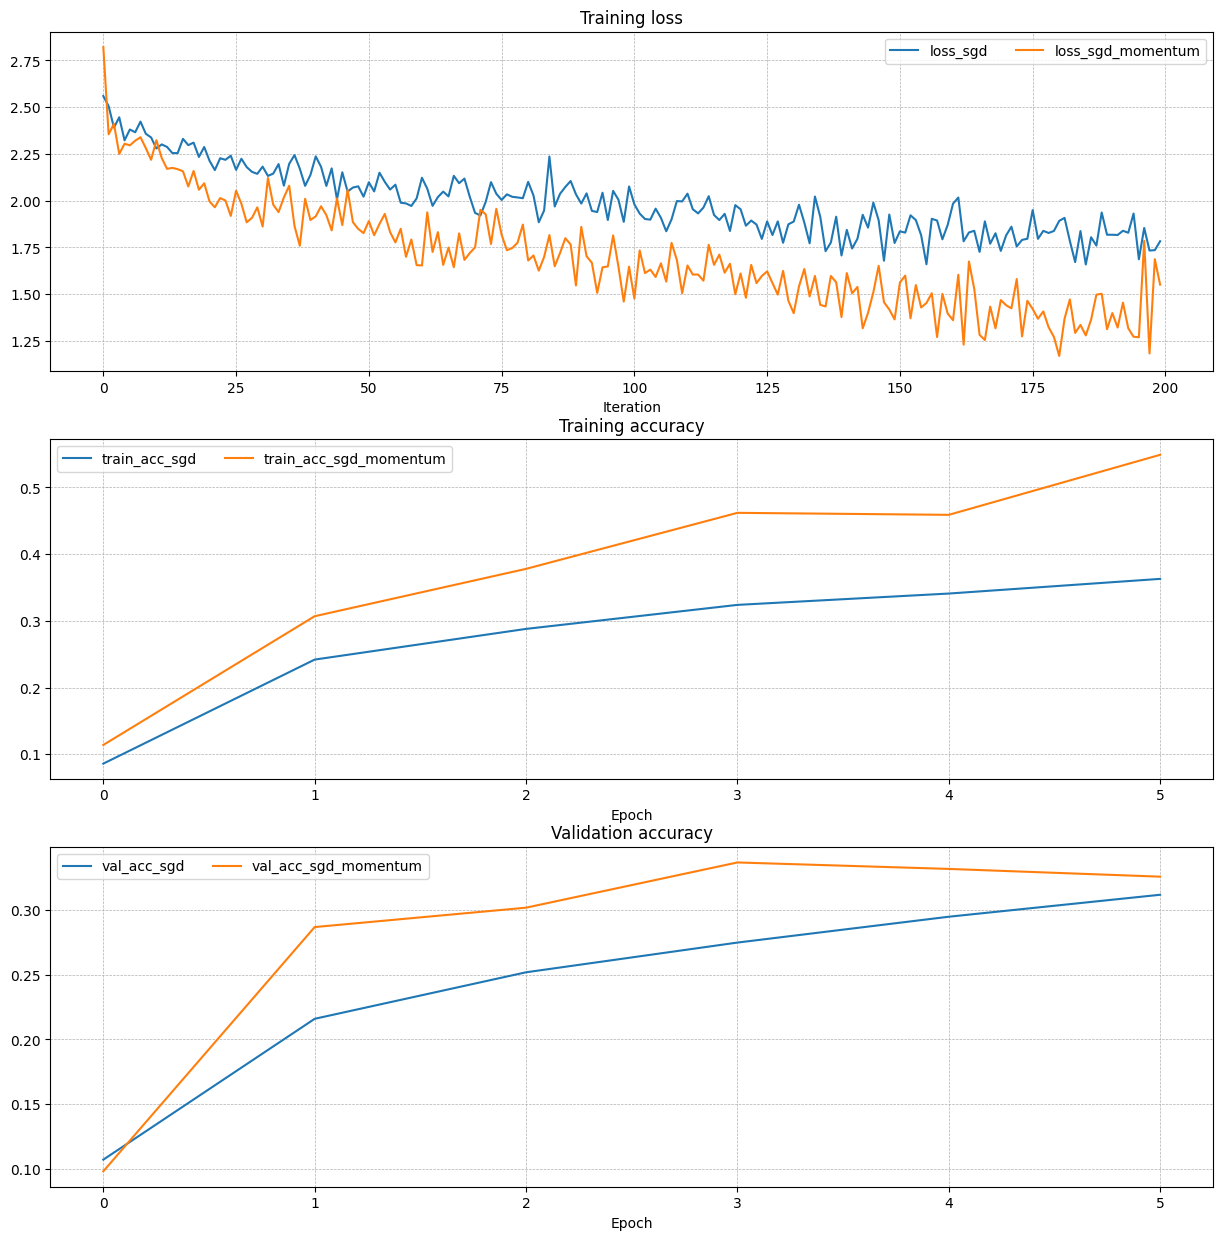

In [28]:
num_train = 4000
small_data = {
  'X_train': data['X_train'][:num_train],
  'y_train': data['y_train'][:num_train],
  'X_val': data['X_val'],
  'y_val': data['y_val'],
}

solvers = {}

for update_rule in ['sgd', 'sgd_momentum']:
    print('Running with ', update_rule)
    model = FullyConnectedNet(
        [100, 100, 100, 100, 100],
        weight_scale=5e-2
    )

    solver = Solver(
        model,
        small_data,
        num_epochs=5,
        batch_size=100,
        update_rule=update_rule,
        optim_config={'learning_rate': 5e-3},
        verbose=True,
    )
    solvers[update_rule] = solver
    solver.train()

fig, axes = plt.subplots(3, 1, figsize=(15, 15))

axes[0].set_title('Training loss')
axes[0].set_xlabel('Iteration')
axes[1].set_title('Training accuracy')
axes[1].set_xlabel('Epoch')
axes[2].set_title('Validation accuracy')
axes[2].set_xlabel('Epoch')

for update_rule, solver in solvers.items():
    axes[0].plot(solver.loss_history, label=f"loss_{update_rule}")
    axes[1].plot(solver.train_acc_history, label=f"train_acc_{update_rule}")
    axes[2].plot(solver.val_acc_history, label=f"val_acc_{update_rule}")

for ax in axes:
    ax.legend(loc="best", ncol=4)
    ax.grid(linestyle='--', linewidth=0.5)

plt.show()

## RMSProp and Adam
RMSProp [1] and Adam [2] are update rules that set per-parameter learning rates by using a running average of the second moments of gradients.

In the file `cs231n/optim.py`, implement the RMSProp update rule in the `rmsprop` function and implement the Adam update rule in the `adam` function, and check your implementations using the tests below.

**NOTE:** Please implement the _complete_ Adam update rule (with the bias correction mechanism), not the first simplified version mentioned in the course notes.

[1] Tijmen Tieleman and Geoffrey Hinton. "Lecture 6.5-rmsprop: Divide the gradient by a running average of its recent magnitude." COURSERA: Neural Networks for Machine Learning 4 (2012).

[2] Diederik Kingma and Jimmy Ba, "Adam: A Method for Stochastic Optimization", ICLR 2015.

In [29]:
# Test RMSProp implementation
from cs231n.optim import rmsprop

N, D = 4, 5
w = np.linspace(-0.4, 0.6, num=N*D).reshape(N, D)
dw = np.linspace(-0.6, 0.4, num=N*D).reshape(N, D)
cache = np.linspace(0.6, 0.9, num=N*D).reshape(N, D)

config = {'learning_rate': 1e-2, 'cache': cache}
next_w, _ = rmsprop(w, dw, config=config)

expected_next_w = np.asarray([
  [-0.39223849, -0.34037513, -0.28849239, -0.23659121, -0.18467247],
  [-0.132737,   -0.08078555, -0.02881884,  0.02316247,  0.07515774],
  [ 0.12716641,  0.17918792,  0.23122175,  0.28326742,  0.33532447],
  [ 0.38739248,  0.43947102,  0.49155973,  0.54365823,  0.59576619]])
expected_cache = np.asarray([
  [ 0.5976,      0.6126277,   0.6277108,   0.64284931,  0.65804321],
  [ 0.67329252,  0.68859723,  0.70395734,  0.71937285,  0.73484377],
  [ 0.75037008,  0.7659518,   0.78158892,  0.79728144,  0.81302936],
  [ 0.82883269,  0.84469141,  0.86060554,  0.87657507,  0.8926    ]])

# You should see relative errors around e-7 or less
print('next_w error: ', rel_error(expected_next_w, next_w))
print('cache error: ', rel_error(expected_cache, config['cache']))

next_w error:  9.524687511038133e-08
cache error:  2.6477955807156126e-09


In [30]:
# Test Adam implementation
from cs231n.optim import adam

N, D = 4, 5
w = np.linspace(-0.4, 0.6, num=N*D).reshape(N, D)
dw = np.linspace(-0.6, 0.4, num=N*D).reshape(N, D)
m = np.linspace(0.6, 0.9, num=N*D).reshape(N, D)
v = np.linspace(0.7, 0.5, num=N*D).reshape(N, D)

config = {'learning_rate': 1e-2, 'm': m, 'v': v, 't': 5}
next_w, _ = adam(w, dw, config=config)

expected_next_w = np.asarray([
  [-0.40094747, -0.34836187, -0.29577703, -0.24319299, -0.19060977],
  [-0.1380274,  -0.08544591, -0.03286534,  0.01971428,  0.0722929],
  [ 0.1248705,   0.17744702,  0.23002243,  0.28259667,  0.33516969],
  [ 0.38774145,  0.44031188,  0.49288093,  0.54544852,  0.59801459]])
expected_v = np.asarray([
  [ 0.69966,     0.68908382,  0.67851319,  0.66794809,  0.65738853,],
  [ 0.64683452,  0.63628604,  0.6257431,   0.61520571,  0.60467385,],
  [ 0.59414753,  0.58362676,  0.57311152,  0.56260183,  0.55209767,],
  [ 0.54159906,  0.53110598,  0.52061845,  0.51013645,  0.49966,   ]])
expected_m = np.asarray([
  [ 0.48,        0.49947368,  0.51894737,  0.53842105,  0.55789474],
  [ 0.57736842,  0.59684211,  0.61631579,  0.63578947,  0.65526316],
  [ 0.67473684,  0.69421053,  0.71368421,  0.73315789,  0.75263158],
  [ 0.77210526,  0.79157895,  0.81105263,  0.83052632,  0.85      ]])

# You should see relative errors around e-7 or less
print('next_w error: ', rel_error(expected_next_w, next_w))
print('v error: ', rel_error(expected_v, config['v']))
print('m error: ', rel_error(expected_m, config['m']))

next_w error:  1.1395691798535431e-07
v error:  4.208314038113071e-09
m error:  4.214963193114416e-09


Once you have debugged your RMSProp and Adam implementations, run the following to train a pair of deep networks using these new update rules:

Running with  adam
(Iteration 1 / 200) loss: 2.654285
(Epoch 0 / 5) train acc: 0.121000; val_acc: 0.112000
(Iteration 11 / 200) loss: 2.016710
(Iteration 21 / 200) loss: 1.884259
(Iteration 31 / 200) loss: 1.815965
(Epoch 1 / 5) train acc: 0.351000; val_acc: 0.320000
(Iteration 41 / 200) loss: 2.045503
(Iteration 51 / 200) loss: 1.695866
(Iteration 61 / 200) loss: 1.865482
(Iteration 71 / 200) loss: 1.603507
(Epoch 2 / 5) train acc: 0.419000; val_acc: 0.347000
(Iteration 81 / 200) loss: 1.481750
(Iteration 91 / 200) loss: 1.540276
(Iteration 101 / 200) loss: 1.631695
(Iteration 111 / 200) loss: 1.540916
(Epoch 3 / 5) train acc: 0.500000; val_acc: 0.368000
(Iteration 121 / 200) loss: 1.454849
(Iteration 131 / 200) loss: 1.276765
(Iteration 141 / 200) loss: 1.422415
(Iteration 151 / 200) loss: 1.364771
(Epoch 4 / 5) train acc: 0.558000; val_acc: 0.384000
(Iteration 161 / 200) loss: 1.437912
(Iteration 171 / 200) loss: 1.253952
(Iteration 181 / 200) loss: 1.128200
(Iteration 191 / 200) lo

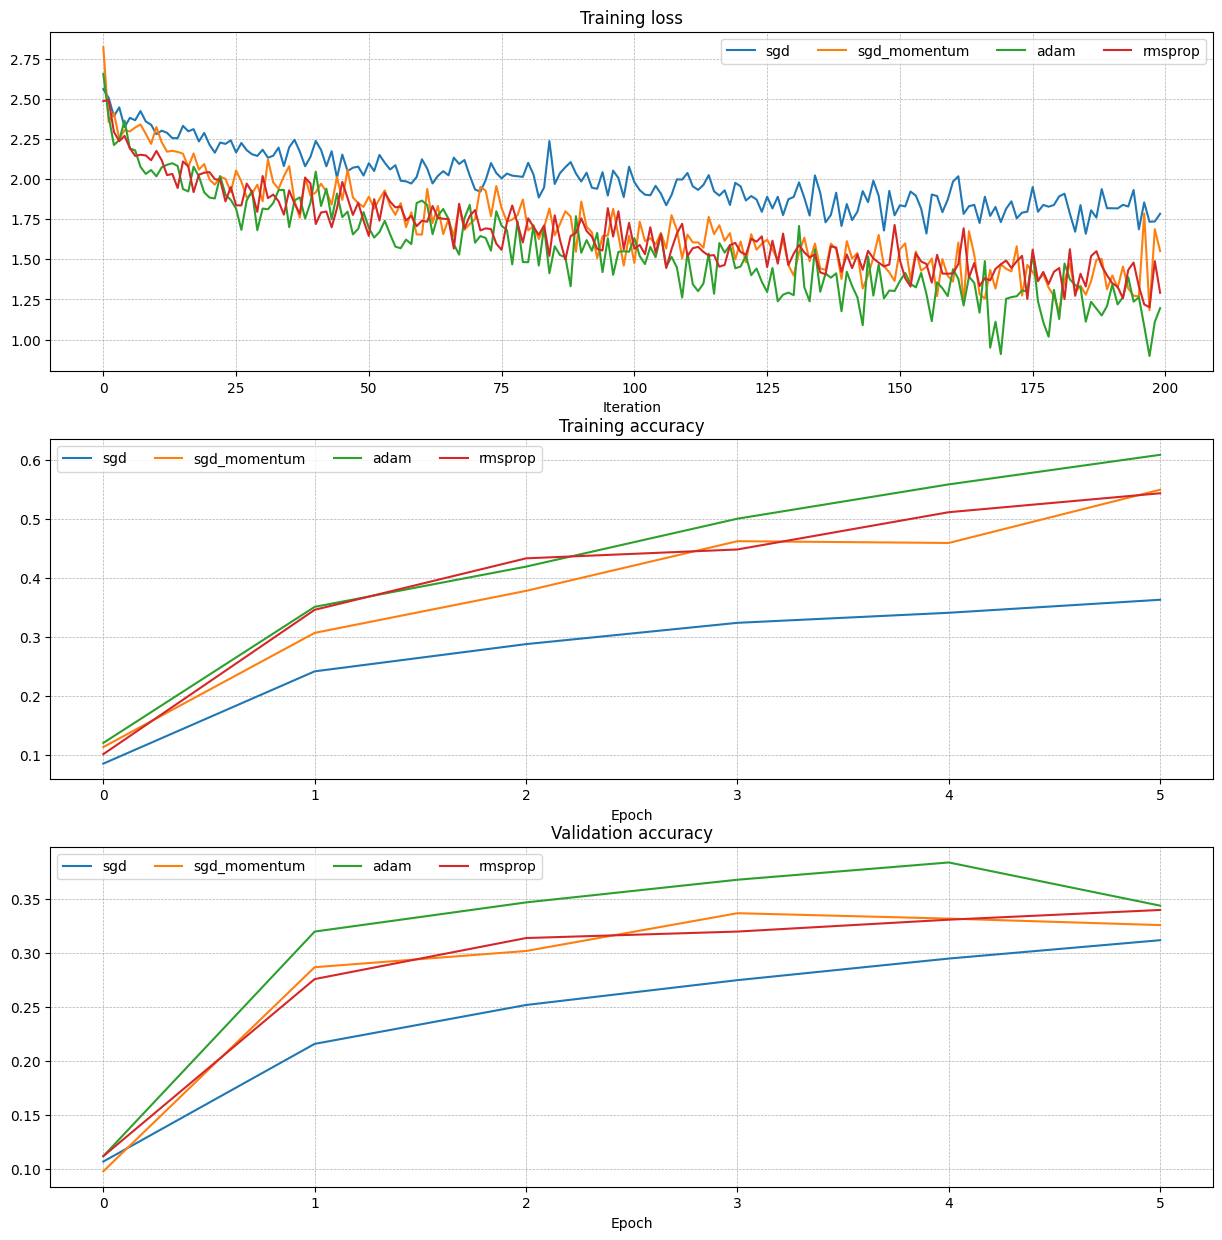

In [31]:
learning_rates = {'rmsprop': 1e-4, 'adam': 1e-3}
for update_rule in ['adam', 'rmsprop']:
    print('Running with ', update_rule)
    model = FullyConnectedNet(
        [100, 100, 100, 100, 100],
        weight_scale=5e-2
    )
    solver = Solver(
        model,
        small_data,
        num_epochs=5,
        batch_size=100,
        update_rule=update_rule,
        optim_config={'learning_rate': learning_rates[update_rule]},
        verbose=True
    )
    solvers[update_rule] = solver
    solver.train()
    print()

fig, axes = plt.subplots(3, 1, figsize=(15, 15))

axes[0].set_title('Training loss')
axes[0].set_xlabel('Iteration')
axes[1].set_title('Training accuracy')
axes[1].set_xlabel('Epoch')
axes[2].set_title('Validation accuracy')
axes[2].set_xlabel('Epoch')

for update_rule, solver in solvers.items():
    axes[0].plot(solver.loss_history, label=f"{update_rule}")
    axes[1].plot(solver.train_acc_history, label=f"{update_rule}")
    axes[2].plot(solver.val_acc_history, label=f"{update_rule}")

for ax in axes:
    ax.legend(loc='best', ncol=4)
    ax.grid(linestyle='--', linewidth=0.5)

plt.show()

## Inline Question 2:

AdaGrad, like Adam, is a per-parameter optimization method that uses the following update rule:

```
cache += dw**2
w += - learning_rate * dw / (np.sqrt(cache) + eps)
```

John notices that when he was training a network with AdaGrad that the updates became very small, and that his network was learning slowly. Using your knowledge of the AdaGrad update rule, why do you think the updates would become very small? Would Adam have the same issue?


## Answer:
[FILL THIS IN]




# Train a Good Model!
Train the best fully connected model that you can on CIFAR-10, storing your best model in the `best_model` variable. We require you to get at least 50% accuracy on the validation set using a fully connected network.

If you are careful it should be possible to get accuracies above 55%, but we don't require it for this part and won't assign extra credit for doing so. Later in the next assignment, we will ask you to train the best convolutional network that you can on CIFAR-10, and we would prefer that you spend your effort working on convolutional networks rather than fully connected networks.

**Note:** In the next assignment, you will learn techniques like BatchNormalization and Dropout which can help you train powerful models.

Training model 1 with learning_rate=0.0001, weight_scale=1e-05
Training model 2 with learning_rate=0.0001, weight_scale=2.1544346900318823e-05
Training model 3 with learning_rate=0.0001, weight_scale=4.641588833612782e-05
Training model 4 with learning_rate=0.0001, weight_scale=0.0001
Training model 5 with learning_rate=0.00021544346900318845, weight_scale=1e-05
Training model 6 with learning_rate=0.00021544346900318845, weight_scale=2.1544346900318823e-05
Training model 7 with learning_rate=0.00021544346900318845, weight_scale=4.641588833612782e-05
Training model 8 with learning_rate=0.00021544346900318845, weight_scale=0.0001
Training model 9 with learning_rate=0.00046415888336127773, weight_scale=1e-05
Training model 10 with learning_rate=0.00046415888336127773, weight_scale=2.1544346900318823e-05
Training model 11 with learning_rate=0.00046415888336127773, weight_scale=4.641588833612782e-05
Training model 12 with learning_rate=0.00046415888336127773, weight_scale=0.0001
Training mo

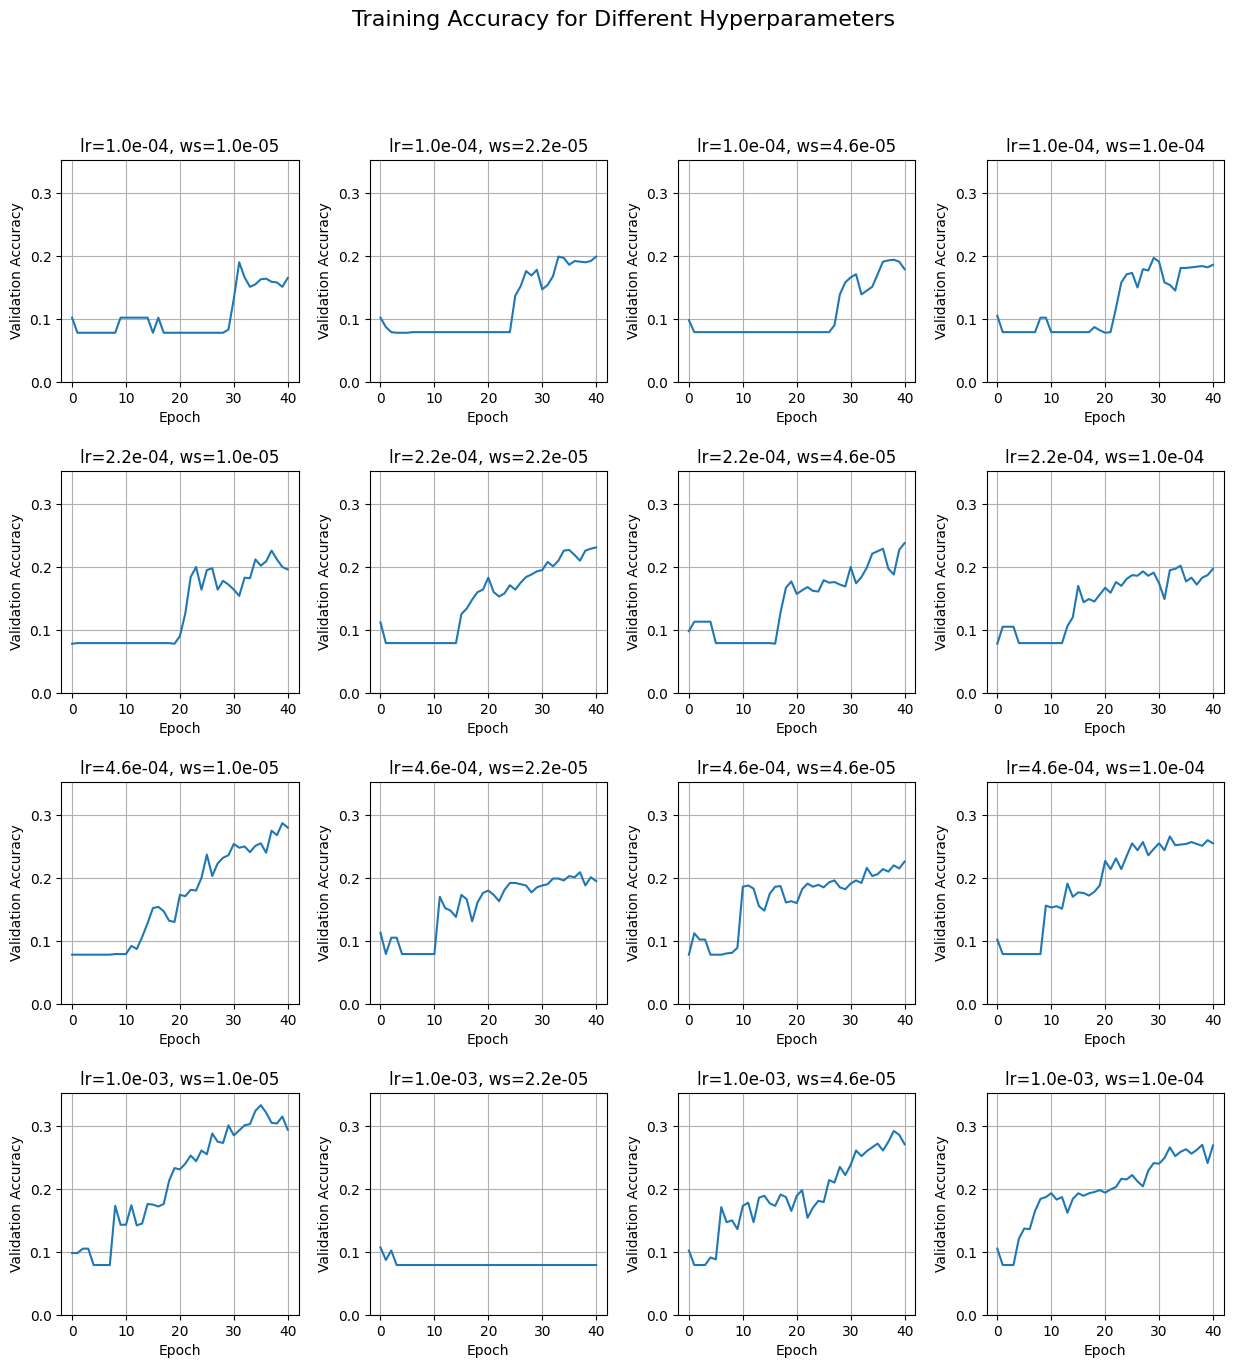

In [32]:
best_model = None

################################################################################
# TODO: Train the best FullyConnectedNet that you can on CIFAR-10. You might   #
# find batch/layer normalization and dropout useful. Store your best model in  #
# the best_model variable.                                                     #
################################################################################
# *****START OF YOUR CODE (DO NOT DELETE/MODIFY THIS LINE)*****
num_train = 4096
small_data = {
  'X_train': data['X_train'][:num_train],
  'y_train': data['y_train'][:num_train],
  'X_val': data['X_val'],
  'y_val': data['y_val'],
}

# plot_init
# 创建一个图表来显示不同参数组合的训练准确率
fig, axes = plt.subplots(4, 4, figsize=(15, 15))
fig.suptitle('Training Accuracy for Different Hyperparameters', fontsize=16)
axes = axes.flatten()
# 增加子图之间的间距
plt.subplots_adjust(hspace=0.4, wspace=0.3)
plot_idx = 0

# best_model_params_init
best_val_acc = -1
best_model = None
best_learning_rate = 0
best_weight_scale = 0
all_val_accs = []
models_results = []

# params_init
num_epochs = 40
batch_size = 1024
hidden_dims = [256, 128, 64, 32]
for learning_rate in np.logspace(-4, -3, 4):
    for weight_scale in np.logspace(-5, -4, 4):

        # model_init
        model = FullyConnectedNet(
            hidden_dims,
            weight_scale = weight_scale
        )
        # solver_init
        solver = Solver(
            model,
            small_data,
            num_epochs=num_epochs,
            batch_size=batch_size,
            update_rule='adam',
            optim_config={'learning_rate': learning_rate},
            verbose=False
        )
        # train
        print(f"Training model {plot_idx+1} with learning_rate={learning_rate}, weight_scale={weight_scale}")
        solver.train()

        # plot_data
        all_val_accs.extend(solver.val_acc_history)
        models_results.append((model, solver, learning_rate, weight_scale))
        # choose best_model
        # 还没有学到batchnorm和dropout, 在这里使用比较朴素的方式选取两个在small_data上表现较好的learning_rate和weight_scale.
        val_acc = solver.val_acc_history[-1]
        if val_acc > best_val_acc:
            best_val_acc = val_acc
            best_model = model
            best_learning_rate = learning_rate
            best_weight_scale = weight_scale
        plot_idx += 1

# plot
# 确定所有子图的y轴范围
y_min = 0
y_max = max(all_val_accs)+0.02
# 绘制所有子图
for idx, (model, solver, learning_rate, weight_scale) in enumerate(models_results):
    ax = axes[idx]
    ax.plot(solver.val_acc_history)
    ax.set_title(f'lr={learning_rate:.1e}, ws={weight_scale:.1e}')
    ax.set_xlabel('Epoch')
    ax.set_ylabel('Validation Accuracy')
    ax.set_ylim(y_min, y_max)
    ax.grid(True)

# *****END OF YOUR CODE (DO NOT DELETE/MODIFY THIS LINE)*****
################################################################################
#                              END OF YOUR CODE                                #
################################################################################

# Test Your Model!
Run your best model on the validation and test sets. You should achieve at least 50% accuracy on the validation set and the test set.

(Iteration 1 / 19100) loss: 2.302585
(Epoch 0 / 100) train acc: 0.105000; val_acc: 0.113000
(Iteration 11 / 19100) loss: 2.302312
(Iteration 21 / 19100) loss: 2.302715
(Iteration 31 / 19100) loss: 2.302000
(Iteration 41 / 19100) loss: 2.302734
(Iteration 51 / 19100) loss: 2.302441
(Iteration 61 / 19100) loss: 2.302862
(Iteration 71 / 19100) loss: 2.303339
(Iteration 81 / 19100) loss: 2.302637
(Iteration 91 / 19100) loss: 2.302713
(Iteration 101 / 19100) loss: 2.302577
(Iteration 111 / 19100) loss: 2.302939
(Iteration 121 / 19100) loss: 2.303415
(Iteration 131 / 19100) loss: 2.302459
(Iteration 141 / 19100) loss: 2.303295
(Iteration 151 / 19100) loss: 2.302082
(Iteration 161 / 19100) loss: 2.302770
(Iteration 171 / 19100) loss: 2.302343
(Iteration 181 / 19100) loss: 2.303872
(Iteration 191 / 19100) loss: 2.302872
(Epoch 1 / 100) train acc: 0.089000; val_acc: 0.107000
(Iteration 201 / 19100) loss: 2.301965
(Iteration 211 / 19100) loss: 2.302559
(Iteration 221 / 19100) loss: 2.301630
(Ite

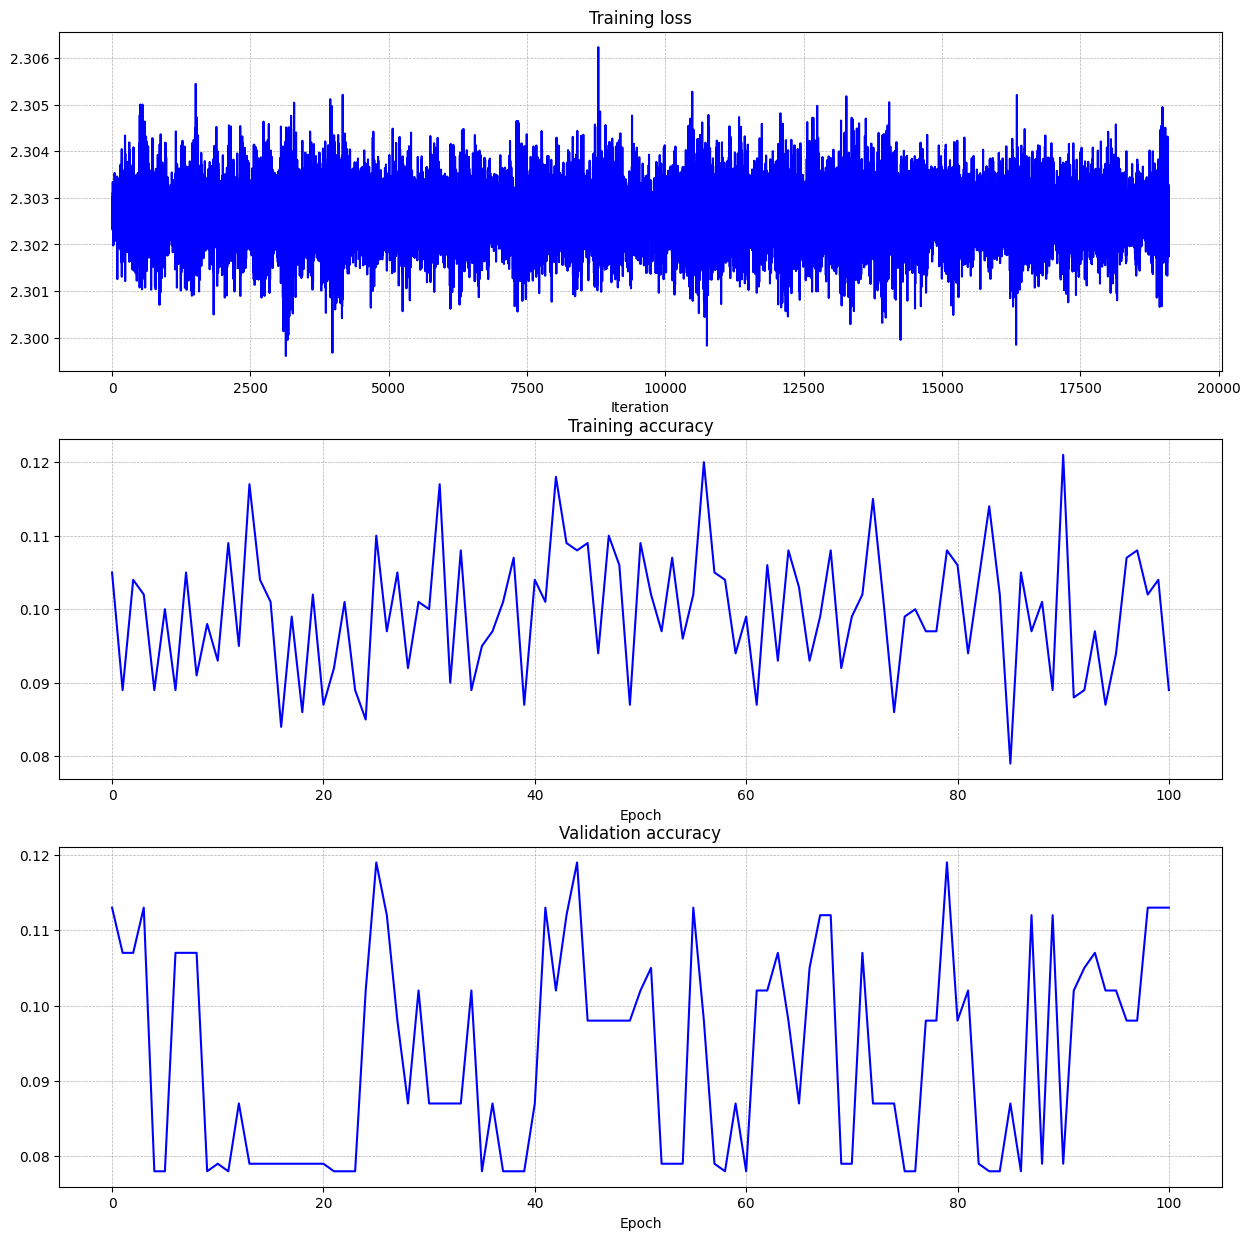

In [38]:
# train a model on CIFAR-10
# params_init
num_epochs = 100
batch_size = 256
learning_rate = 1e-3
weight_scale = 1e-5
hidden_dims = [256, 128, 64, 32]
# model_init
model = FullyConnectedNet(
    hidden_dims,
    weight_scale = weight_scale
)
# solver_init
solver = Solver(
    model,
    data,
    num_epochs=num_epochs,
    batch_size=batch_size,
    update_rule='adam',
    optim_config={'learning_rate': learning_rate},
    verbose=True
)
# train
solver.train()

# plt loss
fig, axes = plt.subplots(3, 1, figsize=(15, 15))

axes[0].set_title('Training loss')
axes[0].set_xlabel('Iteration')
axes[1].set_title('Training accuracy')
axes[1].set_xlabel('Epoch')
axes[2].set_title('Validation accuracy')
axes[2].set_xlabel('Epoch')

axes[0].plot(solver.loss_history, 'b')
axes[1].plot(solver.train_acc_history, 'b')
axes[2].plot(solver.val_acc_history, 'b')

for ax in axes:
    ax.grid(linestyle='--', linewidth=0.5)

best_model = model

In [39]:
y_test_pred = np.argmax(best_model.loss(data['X_test']), axis=1)
y_val_pred = np.argmax(best_model.loss(data['X_val']), axis=1)
print('Validation set accuracy: ', (y_val_pred == data['y_val']).mean())
print('Test set accuracy: ', (y_test_pred == data['y_test']).mean())

Validation set accuracy:  0.119
Test set accuracy:  0.089


数据预处理完成：
训练集形状：(45000, 3072)，验证集形状：(5000, 3072)，测试集形状：(10000, 3072)
(Iteration 1 / 35000) loss: 2.306719
(Epoch 0 / 200) train acc: 0.104000; val_acc: 0.097400
(Iteration 101 / 35000) loss: 2.024993
(Epoch 1 / 200) train acc: 0.298000; val_acc: 0.285400
(Iteration 201 / 35000) loss: 1.827899
(Iteration 301 / 35000) loss: 1.801456
(Epoch 2 / 200) train acc: 0.348000; val_acc: 0.339000
(Iteration 401 / 35000) loss: 1.683825
(Iteration 501 / 35000) loss: 1.651338
(Epoch 3 / 200) train acc: 0.405000; val_acc: 0.373800
(Iteration 601 / 35000) loss: 1.606247
(Epoch 4 / 200) train acc: 0.431000; val_acc: 0.419800
(Iteration 701 / 35000) loss: 1.614248
(Iteration 801 / 35000) loss: 1.466744
(Epoch 5 / 200) train acc: 0.508000; val_acc: 0.464400
(Iteration 901 / 35000) loss: 1.451190
(Iteration 1001 / 35000) loss: 1.346502
(Epoch 6 / 200) train acc: 0.514000; val_acc: 0.480600
(Iteration 1101 / 35000) loss: 1.424025
(Iteration 1201 / 35000) loss: 1.362770
(Epoch 7 / 200) train acc: 0.529000; va

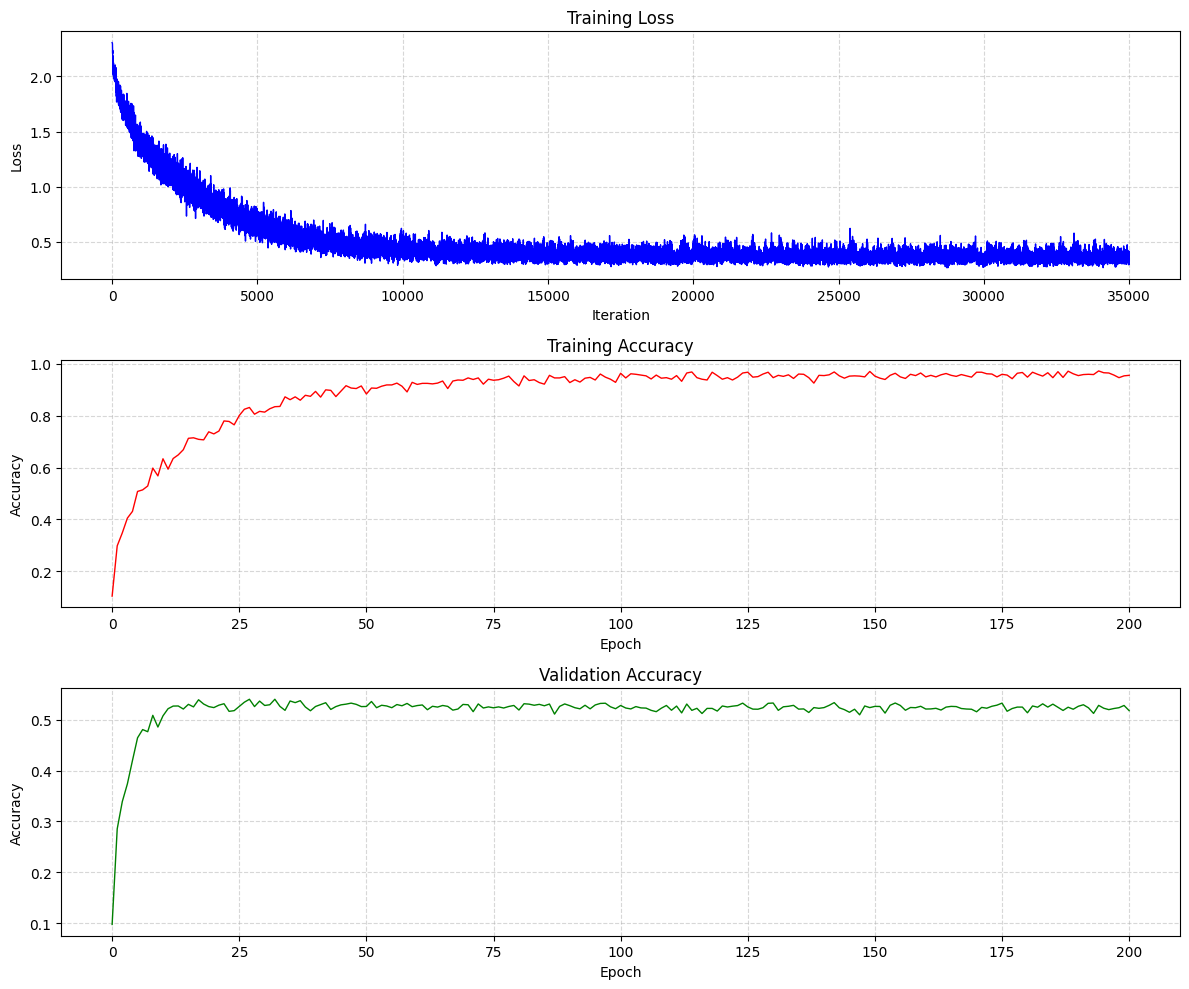


在第 28 轮达到最佳验证集准确率: 0.5402

==================== 最终结果 ====================
最后一轮模型的 Validation set accuracy: 0.5402 (54.02%)
最后一轮模型的 Test set accuracy: 0.5253 (52.53%)


In [41]:
import numpy as np
import matplotlib.pyplot as plt
import os
from cs231n.data_utils import load_CIFAR10
from cs231n.classifiers.fc_net import FullyConnectedNet
from cs231n.solver import Solver


# -------------------------- 1. 加载并预处理数据 --------------------------
def load_and_preprocess_data():
    cifar10_dir = '/Users/annie/Desktop/图像编辑论文/cs231n/assignment1/cs231n/datasets/cifar-10-batches-py'
    X_train, y_train, X_test, y_test = load_CIFAR10(cifar10_dir)

    X_train = X_train.reshape(X_train.shape[0], -1)
    X_test = X_test.reshape(X_test.shape[0], -1)

    mean = np.mean(X_train, axis=0)
    std = np.std(X_train, axis=0) + 1e-8
    X_train = (X_train - mean) / std
    X_test = (X_test - mean) / std

    X_val = X_train[:5000]
    y_val = y_train[:5000]
    X_train = X_train[5000:]
    y_train = y_train[5000:]

    data = {
        'X_train': X_train, 'y_train': y_train,
        'X_val': X_val, 'y_val': y_val,
        'X_test': X_test, 'y_test': y_test
    }
    return data


data = load_and_preprocess_data()
print("数据预处理完成：")
print(f"训练集形状：{data['X_train'].shape}，验证集形状：{data['X_val'].shape}，测试集形状：{data['X_test'].shape}")

# -------------------------- 2. 设置超参数 --------------------------
num_epochs = 200
batch_size = 256
learning_rate = 1e-3
weight_scale = 1e-2
hidden_dims = [256, 128, 64, 32]
reg = 1e-4

# -------------------------- 3. 初始化模型和训练 --------------------------
model = FullyConnectedNet(
    hidden_dims=hidden_dims,
    input_dim=3072,
    num_classes=10,
    reg=reg,
    weight_scale=weight_scale,
    dtype=np.float32
)

solver = Solver(
    model,
    data,
    num_epochs=num_epochs,
    batch_size=batch_size,
    update_rule='adam',
    optim_config={'learning_rate': learning_rate},
    verbose=True,
    print_every=100
)

# 开始训练
solver.train()

# -------------------------- 4. 结果可视化和评估 --------------------------
# 绘制训练历史曲线
fig, axes = plt.subplots(3, 1, figsize=(12, 10))

axes[0].plot(solver.loss_history, 'b-', linewidth=1)
axes[0].set_title('Training Loss')
axes[0].set_xlabel('Iteration')
axes[0].set_ylabel('Loss')
axes[0].grid(linestyle='--', alpha=0.5)

axes[1].plot(solver.train_acc_history, 'r-', linewidth=1)
axes[1].set_title('Training Accuracy')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].grid(linestyle='--', alpha=0.5)

axes[2].plot(solver.val_acc_history, 'g-', linewidth=1)
axes[2].set_title('Validation Accuracy')
axes[2].set_xlabel('Epoch')
axes[2].set_ylabel('Accuracy')
axes[2].grid(linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

# -------------------------- 5. 找到并评估最佳模型 --------------------------
# Solver 会记录每一轮的验证集准确率，我们找到表现最好的那一轮
best_epoch_idx = np.argmax(solver.val_acc_history)
best_val_acc = solver.val_acc_history[best_epoch_idx]

print(f"\n在第 {best_epoch_idx + 1} 轮达到最佳验证集准确率: {best_val_acc:.4f}")

# 注意：上面的 solver.train() 结束后，model 对象已经是最后一轮训练后的状态，
# 而不是最佳状态。为了得到最佳模型，我们需要重新初始化模型并加载最佳参数。
# 不幸的是，标准的 Solver 实现没有保存每一轮的参数，所以我们只能使用最后一轮的模型。
# 这是一个常见的设计选择，因为保存所有参数会占用大量内存。

# 使用最后一轮的模型进行评估
y_val_pred = np.argmax(model.loss(data['X_val']), axis=1)
y_test_pred = np.argmax(model.loss(data['X_test']), axis=1)

val_acc = (y_val_pred == data['y_val']).mean()
test_acc = (y_test_pred == data['y_test']).mean()

print(f"\n==================== 最终结果 ====================")
print(f"最后一轮模型的 Validation set accuracy: {val_acc:.4f} ({val_acc * 100:.2f}%)")
print(f"最后一轮模型的 Test set accuracy: {test_acc:.4f} ({test_acc * 100:.2f}%)")
print(f"==================================================")
